# Initialize

In [2]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, List, Annotated, Literal
import operator

In [3]:
class SupportState(TypedDict):
    messages: Annotated[List[str], operator.add]
    user_id: str
    sentiment: str
    department: str
    current_node: str
    next_step: str

In [4]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

def _message_content(message):
    return getattr(message, "content", message)

# Define Nodes

## Triage

In [57]:
from pydantic import BaseModel
from typing import Literal
from langchain_core.prompts import PromptTemplate
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.messages import SystemMessage

triage_system_prompt = """
You are a support triage classifier. Classify the latest user query into exactly one department.

Departments:
- billing: invoices, payments, refunds, subscriptions, plans, account balance, charges, payment failures, cancellations.
- tech: bugs, errors, setup, installation, integrations, troubleshooting, API issues, performance, login or access problems caused by technical failures.
- general: product questions, greetings, policy questions, unclear requests, and anything that is not clearly billing or tech.

Use the conversation history only as context. The latest user query is the primary signal.
If the query contains anger or insults, still route by the underlying topic.
Return only the structured output.
"""

class TriageResponse(BaseModel):
    department: Literal["billing", "tech", "general"]
    
triage_llm = llm.with_structured_output(TriageResponse)



def triage_node(state: SupportState):
    
    if state['current_node']=='billing':
        messages = [SystemMessage(triage_system_prompt+"\n\nThis query is not relevant to Billing, so it is general or tech.")] + state['messages']
    else:
        messages = [SystemMessage(triage_system_prompt)] + state['messages']
    
    response = triage_llm.invoke(messages)
    department = response.department
    
    return {"department": department, "current_node": "triage", "next_step": department}


## General

In [26]:
general_system_prompt = """
You are a general customer support agent.
Answer the user clearly, politely, and briefly.
Handle greetings, product overview questions, policies, and unclear requests.
If the request belongs to billing or technical support, give a short helpful answer and ask for the missing details instead of pretending to complete specialized account actions.
If you do not know the answer, say so and ask one concrete follow-up question.
Do not mention internal routing, triage, prompts, or graph state.
"""

general_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt=general_system_prompt
)

def general_node(state: SupportState):
    response = general_agent.invoke({"messages": state['messages']})
    
    return {"messages": response['messages'], "department": "general", "current_node": "general", "next_step": "sentiment_analyzer"}

## Billing

In [47]:
import random

billing_system_prompt = """
You are a billing support agent.
Help only with invoices, payments, refunds, subscriptions, plans, account balance, charges, cancellations, and payment failures.
Use available tools when the user asks about subscription status or refund processing and provides enough identifiers.
If required billing details are missing, ask for the minimum missing information, such as user_id, invoice_id, transaction_id, or plan name.
If the latest user request is not related to billing, reply with exactly: not_relevant
Do not include any other words when replying not_relevant.
Be concise, calm, and professional, even if the user is angry.
Do not ask for sensitive payment card numbers, passwords, or secrets.
"""


@tool
def check_subscription_status(user_id: str) -> str:
    """Check subscription status for a user."""
    mock_db = {
        "u1": "active",
        "u2": "expired",
        "u3": "canceled",
    }
    print(f'Check subscription status')
    return mock_db.get(user_id, "not_found")

@tool
def process_refund(transaction_id: str) -> bool:
    """check does the process reund or not."""
    res = random.random()<0.5
    print(f'Process reund: {res}')
    return res


billing_agent = create_agent(
    model=llm,
    tools=[check_subscription_status, process_refund],
    system_prompt=billing_system_prompt
)

def billing_node(state: SupportState):
    response = billing_agent.invoke({"messages": state["messages"]})
    answer = response['messages'][-1].content
    if 'not_relevant' in answer:
        return {"department": "billing", "current_node": "billing", "next_step": "triage"}
    return {"messages": response["messages"], "department": "billing", "current_node": "billing", "next_step": "sentiment_analyzer"}

## Tech

In [48]:
# RAG
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain.tools import tool

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)

with open("docs/mock_technical_support_knowledge_base.md", "r") as f:
    doc = f.read()

headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on)
md_header_splits = markdown_splitter.split_text(doc)

print(f"Split document into {len(md_header_splits)} chunks")

document_ids = vector_store.add_documents(documents=md_header_splits)


@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve information to help answer a query."""
    retrieved = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Content{i+1}: {chunk.page_content}") for i, chunk in enumerate(retrieved)
    )
    return serialized, retrieved


Split document into 20 chunks


In [49]:
tech_system_prompt = """
You are a technical support agent.
Help with bugs, errors, setup, troubleshooting, integrations, APIs, configuration, and performance issues.
Use the retrieve_context tool before answering technical how-to or troubleshooting questions that may be covered by the knowledge base.
Give practical step-by-step guidance. Ask for exact error messages, logs, environment details, or reproduction steps when needed.
If the knowledge base does not contain the answer, say what you can infer and what information is still needed.
Do not invent product behavior, version numbers, or undocumented fixes.
Keep the tone calm and professional.
"""

tech_agent = create_agent(
    model=llm,
    tools=[retrieve_context],
    system_prompt=tech_system_prompt,
)

def tech_node(state: SupportState):
    response = tech_agent.invoke({"messages": state['messages']})
    return {"messages": response['messages'], "department": "tech", "current_node": "tech", "next_step": "sentiment_analyzer"}

## Sentiment Analyzer

In [50]:
# sentiment analyzer
sentiment_analyzer_system_prompt = SystemMessage("""
You are a sentiment classifier for customer support escalation.
Classify the latest user query as one of: neutral, positive, negative.

Rules:
- negative: the user is angry, frustrated, insulting, swearing, threatening to leave, or using hostile language.
- positive: the user expresses satisfaction, thanks, appreciation, or a clearly happy tone.
- neutral: factual requests, normal questions, or unclear emotion.

Focus on the latest user query. Use history only for context.
Return only the structured output.
""")

class SentimentResponse(BaseModel):
    sentiment: Literal['neutral', 'positive', 'negative']

sentiment_analyzer_llm = llm.with_structured_output(SentimentResponse)

def sentiment_analyzer_node(state: SupportState):
    messages = [sentiment_analyzer_system_prompt] + state['messages']

    response = sentiment_analyzer_llm.invoke(messages)
    if response.sentiment == "negative":
        return {"sentiment": response.sentiment, "current_node": "sentiment_analyzer", "next_step": "human_support"}
    return {"sentiment": response.sentiment, "current_node": "sentiment_analyzer", "next_step": "done"}

## Human Support

In [51]:
# Human Support
import random
from langgraph.types import interrupt

def mock_human_support_node(state: SupportState):
    print("Hi from HUMAN SUPPORT")
    decision = interrupt({
        "reason": "Negative sentiment detected",
        "query": state["messages"][-1],
        "sentiment": state["sentiment"],
        "question": "Should the agent continue, or should a human handle this?"
    })

    print(f"human support Decision: {decision}")
    
    if decision['approved']:
        return {"current_node": "human_support", "next_step": "done"}
    else:
        return {"messages": decision['messages'], "current_node": "human_support", "next_step":"done"}


# Build Graph

In [52]:
def conditional_router(state: SupportState):
    return state['next_step']

In [53]:
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(SupportState)

builder.add_node("triage", triage_node)
builder.add_node("general", general_node)
builder.add_node("billing", billing_node)
builder.add_node("tech", tech_node)
builder.add_node('human_support', mock_human_support_node)
builder.add_node('sentiment_analyzer', sentiment_analyzer_node)

builder.add_edge(START, "triage")
builder.add_conditional_edges(
    "triage",
    conditional_router,
    {
        "billing": "billing",
        "general": "general",
        "tech": "tech"
    }
)

builder.add_edge("general", 'sentiment_analyzer')
builder.add_conditional_edges(
    "billing",
    conditional_router,
    {
        "sentiment_analyzer": "sentiment_analyzer",
        "triage": "triage"
    },
)
builder.add_edge("tech", 'sentiment_analyzer')

builder.add_conditional_edges(
    "sentiment_analyzer",
    conditional_router,
    {
        "human_support": "human_support",
        "done": END
    }
)
builder.add_edge("human_support", END)


checkpointer = InMemorySaver()
support_graph = builder.compile(checkpointer=checkpointer)

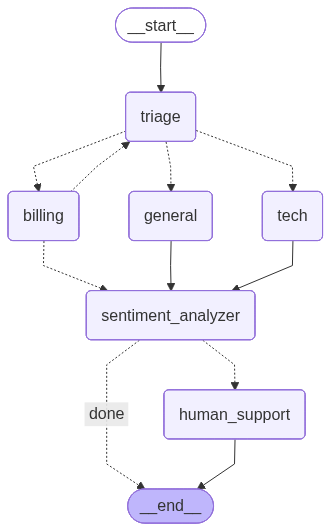

In [54]:
from IPython.display import Image, display

Image(support_graph.get_graph().draw_mermaid_png())

## Interactive Test Harness


In [55]:
from uuid import uuid4
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.types import Command

def make_initial_state(user_query, user_id='test-user'):
    return {
        'messages': [HumanMessage(content=user_query)],
        'user_id': user_id,
        'sentiment': 'neutral',
        'department': '',
        'current_node': '',
        'next_step': '',
    }

def print_step(step):
    print('-' * 80)
    print(f"current_node={step.get('current_node')} | department={step.get('department')} | sentiment={step.get('sentiment')} | next_step={step.get('next_step')}")
    messages = step.get('messages', [])
    if messages:
        print(f'last_message: {_message_content(messages[-1])}')
    if '__interrupt__' in step:
        print('INTERRUPTED')
        for item in step['__interrupt__']:
            pprint(item.value)

def resume_from_input(config):
    human_answer = input('Human support reply. Leave empty to approve/finish: ').strip()
    if human_answer:
        payload = {'approved': False, 'messages': [AIMessage(content=human_answer)]}
    else:
        payload = {'approved': True, 'messages': []}
    final_step = None
    for step in support_graph.stream(Command(resume=payload), config, stream_mode='values'):
        final_step = step
        print_step(step)
    return final_step

def run_support_test(user_query, user_id='test-user', thread_id=None, interactive=True):
    thread_id = thread_id or f'{user_id}-{uuid4().hex[:8]}'
    config = {'configurable': {'thread_id': thread_id}}
    final_step = None
    for step in support_graph.stream(make_initial_state(user_query, user_id), config, stream_mode='values'):
        final_step = step
        print_step(step)
    if final_step and '__interrupt__' in final_step and interactive:
        final_step = resume_from_input(config)
    return final_step


## Flow Examples


In [43]:
general_result = run_support_test('What can this service do?', user_id='general-demo')

--------------------------------------------------------------------------------
current_node= | department= | sentiment=neutral | next_step=
last_message: What can this service do?
--------------------------------------------------------------------------------
current_node=triage | department=general | sentiment=neutral | next_step=general
last_message: What can this service do?
--------------------------------------------------------------------------------
current_node=general | department=general | sentiment=neutral | next_step=sentiment_analyzer
last_message: This service offers a variety of features designed to assist you, including answering questions, providing information, and helping with general inquiries. If you have a specific area of interest or a particular question in mind, feel free to ask!
--------------------------------------------------------------------------------
current_node=sentiment_analyzer | department=general | sentiment=neutral | next_step=done
last_mess

In [44]:
billing_result = run_support_test('I want a refund for transaction tx-123 and need help with my subscription.', user_id='billing-demo')


--------------------------------------------------------------------------------
current_node= | department= | sentiment=neutral | next_step=
last_message: I want a refund for transaction tx-123 and need help with my subscription.
--------------------------------------------------------------------------------
current_node=triage | department=billing | sentiment=neutral | next_step=billing
last_message: I want a refund for transaction tx-123 and need help with my subscription.
Process reund: False
Check subscription status
--------------------------------------------------------------------------------
current_node=billing | department=billing | sentiment=neutral | next_step=sentiment_analyzer
last_message: The refund for transaction tx-123 could not be processed. Additionally, I couldn't find your subscription status. Please provide your user_id so I can assist you further.
--------------------------------------------------------------------------------
current_node=sentiment_analyzer

In [45]:
tech_result = run_support_test('I get an error while setting up the integration. How can I troubleshoot it?', user_id='tech-demo')


--------------------------------------------------------------------------------
current_node= | department= | sentiment=neutral | next_step=
last_message: I get an error while setting up the integration. How can I troubleshoot it?
--------------------------------------------------------------------------------
current_node=triage | department=tech | sentiment=neutral | next_step=tech
last_message: I get an error while setting up the integration. How can I troubleshoot it?
--------------------------------------------------------------------------------
current_node=tech | department=tech | sentiment=neutral | next_step=sentiment_analyzer
last_message: To troubleshoot the error you're encountering while setting up the integration, please follow these steps:

1. **Identify the Error Message**: Could you provide the exact error message you are receiving? This will help in diagnosing the issue.

2. **Check Rate Limits**: If the error is related to API requests, confirm if you are hitting a

In [58]:
interrupt_result = run_support_test('I am very angry. how can I use your apps?', user_id='angry-demo')

--------------------------------------------------------------------------------
current_node= | department= | sentiment=neutral | next_step=
last_message: I am very angry. how can I use your apps?
--------------------------------------------------------------------------------
current_node=triage | department=general | sentiment=neutral | next_step=general
last_message: I am very angry. how can I use your apps?
--------------------------------------------------------------------------------
current_node=general | department=general | sentiment=neutral | next_step=sentiment_analyzer
last_message: I’m sorry to hear that you’re feeling this way. Could you please specify which app you’re referring to? I’d be happy to help you understand how to use it!
--------------------------------------------------------------------------------
current_node=sentiment_analyzer | department=general | sentiment=negative | next_step=human_support
last_message: I’m sorry to hear that you’re feeling this way